# Dynamic range analysis

This notebook goes through the whole dataset and, for every sample and sensing unit (SU), computes the minimum value, maximum value, and dynamic range (maximum - minimum) of the corresponding spectrogram image. The results are stored in a pandas DataFrame with one row per (sample, SU) pair.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from tqdm.notebook import trange

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.data_utils import get_datapath

In [2]:
DATASET_NR = 0
NUM_SU = 21

datapath = get_datapath(_repo_name)
datapath = os.path.join(datapath, str(DATASET_NR))

min_max = pd.read_csv(os.path.join(datapath, "spectrogram_min_max.csv"))
min_val = min_max["min_val"].values[0]
max_val = min_max["max_val"].values[0]

labels = pd.read_csv(os.path.join(datapath, "labels.csv"))
print(f"Number of samples: {len(labels)}")
print(f"Spectrogram value range used for rescaling: {min_val} to {max_val}")

Number of samples: 20000
Spectrogram value range used for rescaling: -183.38843 to 27.147293


In [3]:
def get_filename(sample_idx, su_idx):
    return os.path.join(datapath, "images", f"spectrogram-{str(sample_idx).zfill(5)}-{str(su_idx).zfill(2)}.png")

## Compute min, max, and dynamic range for every sample and SU

This iterates over the whole dataset, so it can take a while depending on the number of samples and SUs.

In [4]:
rows = []

for sample_idx in trange(len(labels)):
    for su_idx in range(NUM_SU):
        img = np.array(Image.open(get_filename(sample_idx, su_idx))) / 255.0 * (max_val - min_val) + min_val
        img_min = float(img.min())
        img_max = float(img.max())
        rows.append(
            {
                "sample_idx": sample_idx,
                "su_idx": su_idx,
                "min_val": img_min,
                "max_val": img_max,
                "dynamic_range": img_max - img_min,
            }
        )

dynamic_range_df = pd.DataFrame(rows)
dynamic_range_df

  0%|          | 0/20000 [00:00<?, ?it/s]

,sample_idx,su_idx,min_val,max_val,dynamic_range
0,0,0,-130.548092,-45.508172,85.039919
1,0,1,-127.245571,-18.262373,108.983198
2,0,2,-122.291789,-27.344306,94.947483
3,0,3,-127.245571,-21.564894,105.680677
4,0,4,-124.768680,-31.472457,93.296222
...,...,...,...,...,...
419995,19999,16,-123.117419,-10.006070,113.111349
419996,19999,17,-131.373722,-5.052288,126.321434
419997,19999,18,-131.373722,-10.831700,120.542022
419998,19999,19,-127.245571,-13.308591,113.936980


In [ ]:
save_results = True
if save_results:
    csv_path = os.path.join(datapath, "spectrogram_dynamic_range.csv")
    dynamic_range_df.to_csv(csv_path, index=False)
    print(f"Saved results to {csv_path}")

## Summary statistics

In [5]:
dynamic_range_df[["min_val", "max_val", "dynamic_range"]].describe()

,min_val,max_val,dynamic_range
count,420000.000000,420000.000000,420000.000000
mean,-124.228442,-29.193985,95.034457
std,8.217411,8.921546,11.972741
min,-183.388430,-65.323299,49.537817
25%,-128.071201,-33.949348,88.342441
50%,-124.768680,-28.995566,94.947483
75%,-120.640528,-24.041785,102.378155
max,-56.241366,27.147293,162.649166


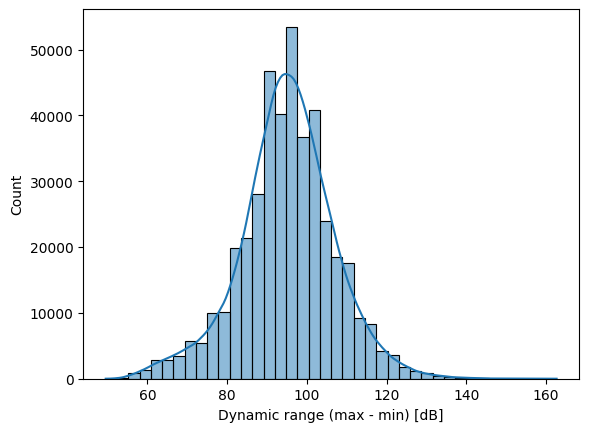

In [9]:
sns.histplot(dynamic_range_df["dynamic_range"], bins=40, kde=True)
plt.xlabel("Dynamic range (max - min) [dB]")
plt.show()

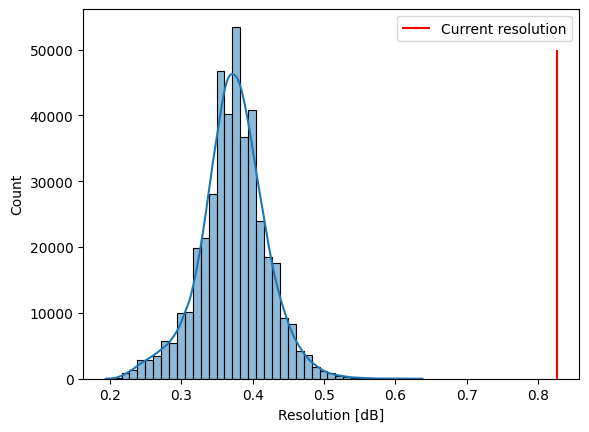

In [12]:
sns.histplot(dynamic_range_df["dynamic_range"] / 255, bins=40, kde=True)
plt.vlines(x=(max_val - min_val) / 255, ymin=0, ymax=50000, color="red", label="Current resolution")
plt.xlabel("Resolution [dB]")
plt.legend()
plt.show()